🎯 載入 SAM: sam2_t.pt
🤖 OpenCV 自動偵測到 22 個有效區塊，開始引導 SAM2...


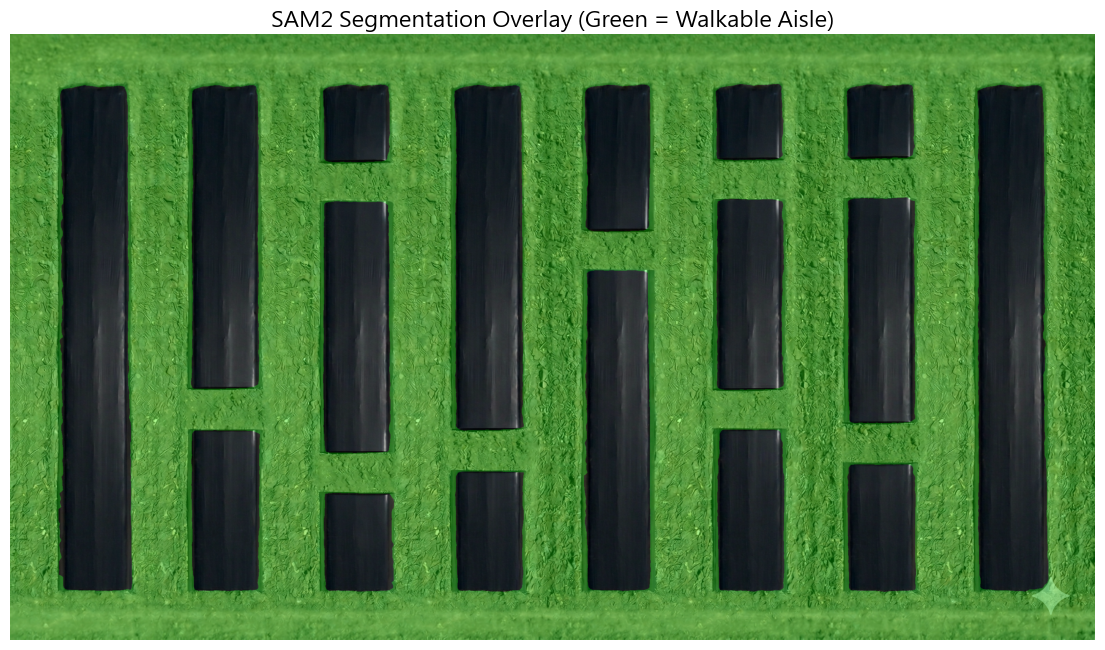

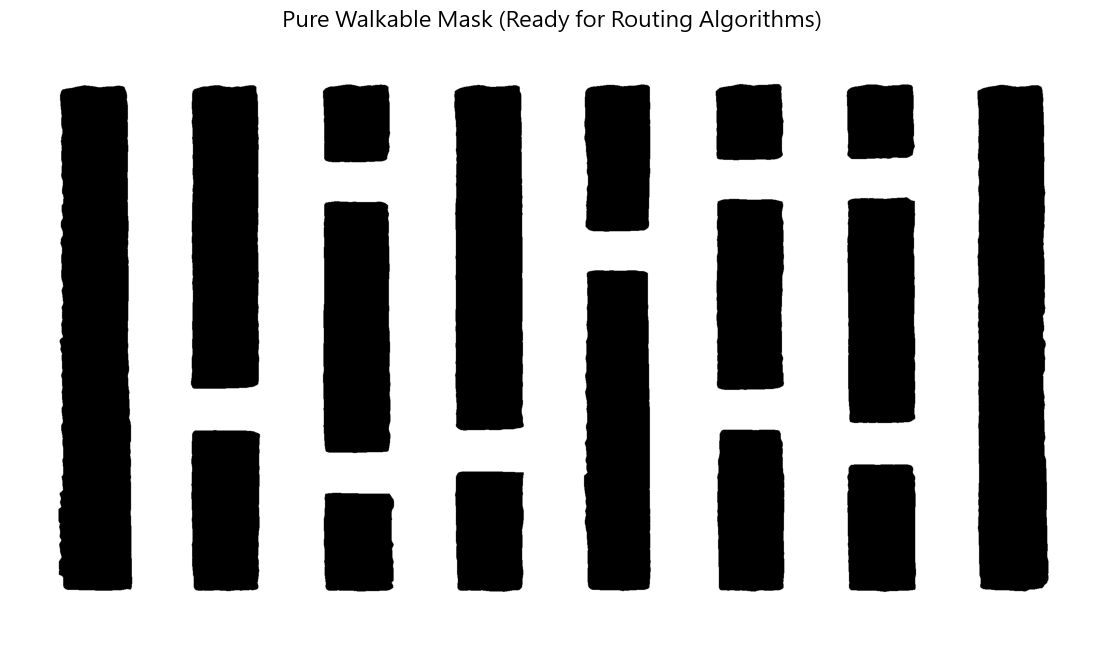

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import SAM

def image_to_aco_grid(image_path, model_path="sam2_t.pt", grid_shape=(39, 22)):
    print(f"🎯 載入 SAM: {model_path}")
    model = SAM(model_path)
    
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"❌ 圖片讀不到: {image_path}")
    h, w = img.shape[:2]
    total_area = h * w

    # =========================================================
    # 🌟 自動提示點生成 (Auto-Prompting)
    # =========================================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)
    
    kernel_cv = np.ones((11, 11), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_cv)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    input_points = []
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 800: 
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                input_points.append([cX, cY])
                
    print(f"🤖 OpenCV 自動偵測到 {len(input_points)} 個有效區塊，開始引導 SAM2...")

    # =========================================================
    # 👁️ SAM2 迭代分割 + 面積防呆
    # =========================================================
    obstacle_mask = np.zeros((h, w), dtype=np.uint8)
    
    for pt in input_points:
        results = model.predict(img, points=[pt], labels=[1], verbose=False)
        if results[0].masks is None: continue
            
        mask = results[0].masks.data.cpu().numpy()[0]
        if np.sum(mask) > total_area * 0.15:
            continue
            
        obstacle_mask = cv2.bitwise_or(obstacle_mask, mask.astype(np.uint8))

    kernel_clean = np.ones((5,5), np.uint8)
    obstacle_mask = cv2.morphologyEx(obstacle_mask, cv2.MORPH_OPEN, kernel_clean)

    # 取得走道遮罩 (255=可走泥土, 0=黑色基肥)
    walkable_mask = (1 - obstacle_mask) * 255
    
    return walkable_mask, img

# ================= 主程式 =================
if __name__ == "__main__":
    image_path = "草莓田模擬平面圖(無草莓).png" # 請確認檔名

    # 只取 mask 跟原圖，不需要 aco_matrix 了
    mask, original_img = image_to_aco_grid(image_path)

    # ================= 視覺化：半透明疊加 (Overlay) =================
    # 創造一個全綠色的圖層
    colored_mask = np.zeros_like(original_img)
    # 將 mask 為 255 的地方（走道）塗成螢光綠 (BGR格式: [0, 255, 0])
    colored_mask[mask == 255] = [0, 255, 0] 

    # 將原圖與綠色遮罩以 7:3 的透明度混合
    overlay_img = cv2.addWeighted(original_img, 0.7, colored_mask, 0.3, 0)

    # 第一張圖：顯示超有科技感的疊加圖
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    plt.title("SAM2 Segmentation Overlay (Green = Walkable Aisle)", fontsize=16)
    plt.axis('off') # 關閉旁邊煩人的刻度數字
    plt.show()

    # 第二張圖：單獨顯示純淨的二值化黑白圖 (留著之後存檔用)
    plt.figure(figsize=(14, 8))
    plt.imshow(mask, cmap='gray')
    plt.title("Pure Walkable Mask (Ready for Routing Algorithms)", fontsize=16)
    plt.axis('off')
    plt.show()

🎯 載入 SAM: sam2_t.pt
📐 系統動態換算結果:
   - 矩陣尺寸: 110 x 195 格
   - 物理尺寸: 19.50m x 11.00m
✅ 動態網格已儲存！物理尺寸: 19.5m x 11.0m


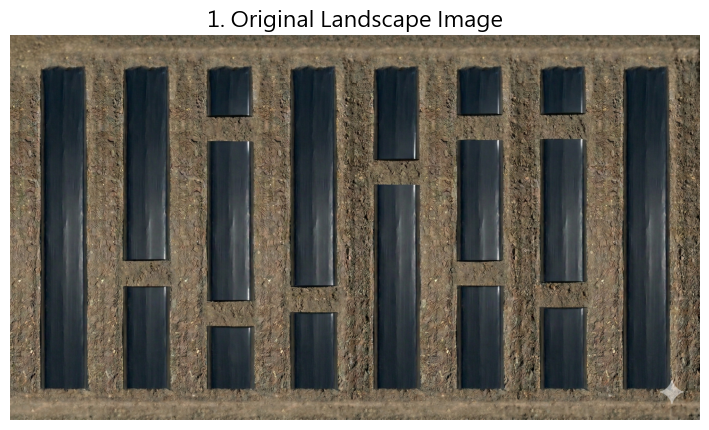

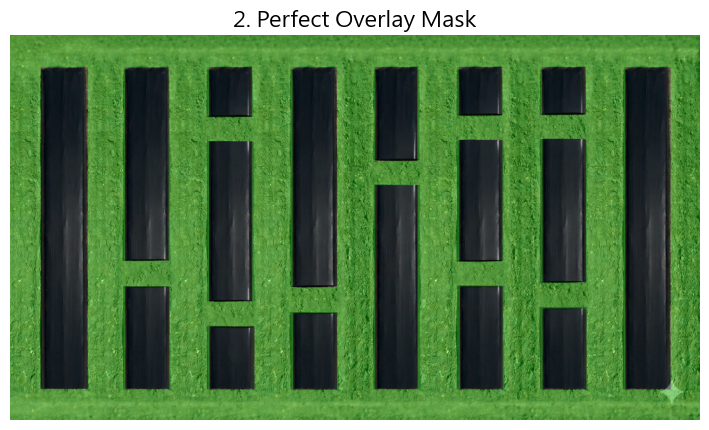

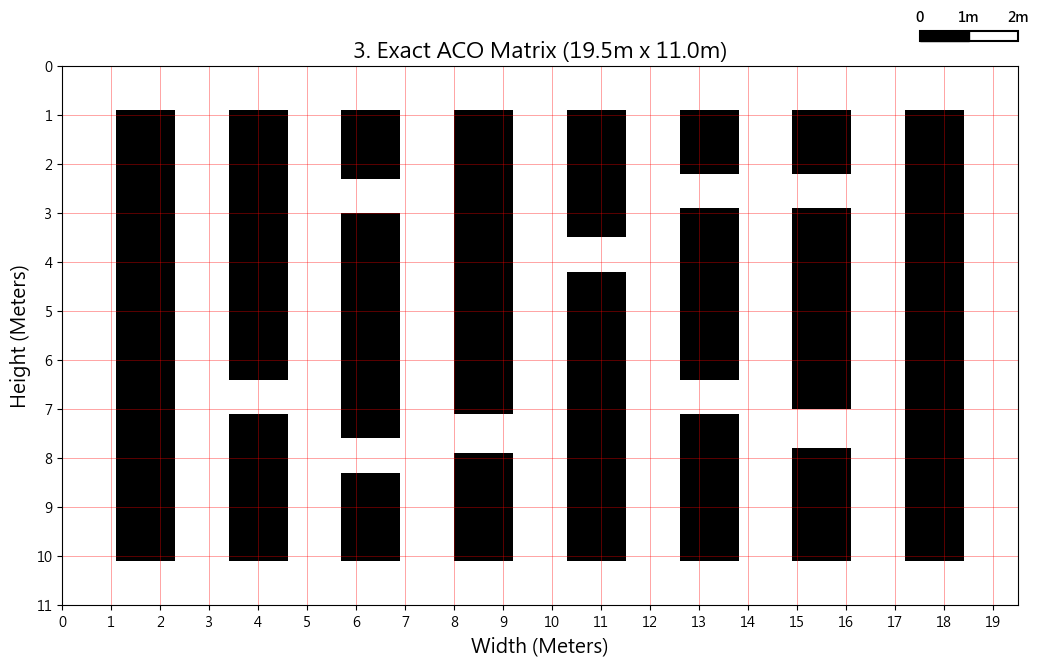

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ultralytics import SAM

# ================= 重構後的建圖與比例尺可視化模組 =================

def load_and_preprocess_image(image_path, model_path="sam2_t.pt", 
                              physical_height_m=11.0, # 農田真實高度 (Y軸)
                              num_lanes=8,            # 幾條基肥壟
                              ridge_width_m=0.7,      # 基肥壟寬度 (公尺)
                              aisle_width_m=0.6,      # 泥土走廊寬度 (公尺)
                              cell_size_m=0.1):       # 網格解析度 (建議 0.1m)
    """
    動態物理建圖：輸入真實公尺，自動換算矩陣，並回傳完整的動態參數字典與乾淨的地圖
    """
    print(f"🎯 載入 SAM: {model_path}")
    model = SAM(model_path)
    
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"❌ 圖片讀不到: {image_path}")
    h, w = img.shape[:2]
    total_area = h * w

    # =========================================================
    # 📐 動態換算：公尺 -> 網格數 (四捨五入取整)
    # =========================================================
    grid_rows = int(round(physical_height_m / cell_size_m))
    ridge_cells = int(round(ridge_width_m / cell_size_m))
    aisle_cells = int(round(aisle_width_m / cell_size_m))
    
    # 計算 X 軸總格數與真實物理寬度
    grid_cols = num_lanes * ridge_cells + (num_lanes + 1) * aisle_cells
    physical_width_m = grid_cols * cell_size_m
    
    print(f"📐 系統動態換算結果:")
    print(f"   - 矩陣尺寸: {grid_rows} x {grid_cols} 格")
    print(f"   - 物理尺寸: {physical_width_m:.2f}m x {physical_height_m:.2f}m")

    # =========================================================
    # 🌟 1. 自動提示點生成 
    # =========================================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)
    kernel_cv = np.ones((11, 11), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_cv)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    input_points = []
    for cnt in contours:
        if cv2.contourArea(cnt) > 800: 
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
                input_points.append([cX, cY])

    # =========================================================
    # 👁️ 2. SAM2 原始分割
    # =========================================================
    raw_obstacle_mask = np.zeros((h, w), dtype=np.uint8)
    for pt in input_points:
        results = model.predict(img, points=[pt], labels=[1], verbose=False)
        if results[0].masks is None: continue
        mask = results[0].masks.data.cpu().numpy()[0]
        if np.sum(mask) > total_area * 0.15: continue
        raw_obstacle_mask = cv2.bitwise_or(raw_obstacle_mask, mask.astype(np.uint8))

    kernel_clean = np.ones((5,5), np.uint8)
    raw_obstacle_mask = cv2.morphologyEx(raw_obstacle_mask, cv2.MORPH_OPEN, kernel_clean)

    # =========================================================
    # 📏 3. 數學強制網格寫入
    # =========================================================
    aco_matrix = np.ones((grid_rows, grid_cols), dtype=np.int8) 
    sam_contours, _ = cv2.findContours(raw_obstacle_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    rects = []
    for cnt in sam_contours:
        if cv2.contourArea(cnt) > 800:
            x, y, w_rect, h_rect = cv2.boundingRect(cnt)
            rects.append((x, y, w_rect, h_rect, x + w_rect//2))
            
    rects.sort(key=lambda item: item[4]) 
    lanes_data = [[] for _ in range(num_lanes)]
    current_lane_idx = 0
    last_cx = rects[0][4]
    
    for rect in rects:
        cx = rect[4]
        if cx - last_cx > w / 16 and current_lane_idx < num_lanes - 1:
            current_lane_idx += 1
        lanes_data[current_lane_idx].append(rect)
        last_cx = cx

    clean_obstacle_mask = np.zeros((h, w), dtype=np.uint8)
    
    for lane_idx, lane_rects in enumerate(lanes_data):
        if not lane_rects: continue
        
        # 動態計算欄位區間 (絕對使用整數 index)
        col_start = (lane_idx + 1) * aisle_cells + lane_idx * ridge_cells
        col_end = col_start + ridge_cells
        
        for (x, y, w_rect, h_rect, cx) in lane_rects:
            grid_r1 = int((y / h) * grid_rows)
            grid_r2 = int(((y + h_rect) / h) * grid_rows)
            
            # 寫入 ACO 矩陣
            aco_matrix[grid_r1:grid_r2, col_start:col_end] = 0
            
            # 高解析度疊加層畫布 (使用 OpenCV 真實像素)
            cv2.rectangle(clean_obstacle_mask, (x, y), (x + w_rect, y + h_rect), 1, -1)

    walkable_mask = (1 - clean_obstacle_mask) * 255
    
    # 將所有不會寫死的動態參數打包回傳
    grid_info = {
        "physical_width_m": physical_width_m,
        "physical_height_m": physical_height_m,
        "cell_size_m": cell_size_m,
        "grid_rows": grid_rows,
        "grid_cols": grid_cols
    }
    
    return aco_matrix, walkable_mask, img, grid_info

def add_professional_map_scale(ax, physical_width_m, cell_size_m, 
                               scale_len_m=2.0, font_size=10):
    """
    在右上角外部佈局畫出一個黑白分段式、空心的專業地圖比例尺
    """
    xmin, xmax = ax.get_xlim() 
    ymin, ymax = ax.get_ylim() 
    
    # 比例尺位置：右上角外部 
    pad_y_above_title = 0.5 
    scale_bar_y_base = ymax - 0.2 - pad_y_above_title 
    scale_bar_x_base = xmax - scale_len_m 

    seg_len_1 = 1.0 
    seg_len_2 = 1.0
    bar_h = 0.2

    # 段 1 (0-1m)：實心黑 Patch 
    p1 = plt.Rectangle((scale_bar_x_base, scale_bar_y_base), seg_len_1, bar_h, color='black', alpha=1)
    
    # 段 2 (1m-2m)：空心透明填滿與黑邊框
    p2 = plt.Rectangle((scale_bar_x_base + seg_len_1, scale_bar_y_base), seg_len_2, bar_h, 
                       facecolor='none', edgecolor='black', lw=1.2, alpha=1) 
    
    # 加入整體比例尺外框
    p_box = plt.Rectangle((scale_bar_x_base, scale_bar_y_base), scale_len_m, bar_h, fill=False, edgecolor='black', lw=1.5, alpha=1)
    
    # 必須手動設定 clipping=False 避免被裁切
    for p in [p1, p2, p_box]:
        p.set_clip_on(False) 
        ax.add_patch(p)
    
    # 5. 加入文字 (0, 1m, 2m)
    ax.text(scale_bar_x_base, scale_bar_y_base - 0.2, "0", color='black', ha='center', fontsize=font_size, fontweight='bold', clip_on=False)
    ax.text(scale_bar_x_base + seg_len_1, scale_bar_y_base - 0.2, "1m", color='black', ha='center', fontsize=font_size, fontweight='bold', clip_on=False)
    # 使用 int() 轉型，讓 f"{scale_len_m}m" 從 "2.0m" 變成乾淨的 "2m"
    ax.text(scale_bar_x_base + scale_len_m, scale_bar_y_base - 0.2, f"{int(scale_len_m)}m", color='black', ha='center', fontsize=font_size, fontweight='bold', clip_on=False)

# ================= 主程式與視覺化 =================
if __name__ == "__main__":
    image_path = "草莓田模擬平面圖(無草莓).png" # 請確認檔名

    aco_matrix, overlay_mask, original_img, info = load_and_preprocess_image(
        image_path, 
        model_path="sam2_t.pt",
        physical_height_m=11.0, # 農田真實高度 (Y軸)
        num_lanes=8,            # 幾條基肥壟
        ridge_width_m=1.2,      # 基肥壟寬度 (公尺)
        aisle_width_m=1.1,      # 泥土走廊寬度 (公尺) 總和為9*1.1m+8*1.2m=19.5m
        cell_size_m=0.1         # 網格解析度 (建議 0.1m)
    )

    w_m = info["physical_width_m"]
    h_m = info["physical_height_m"]
    c_size = info["cell_size_m"]

    np.savetxt("farm_grid_map.csv", aco_matrix, delimiter=",", fmt='%d')
    print(f"✅ 動態網格已儲存！物理尺寸: {w_m:.1f}m x {h_m:.1f}m")

    # ================= 📈 依序印出三張圖片 =================
    
    plt.figure(figsize=(15, 5))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("1. Original Landscape Image", fontsize=16)
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(15, 5))
    colored_mask = np.zeros_like(original_img)
    colored_mask[overlay_mask == 255] = [0, 255, 0] 
    overlay_img = cv2.addWeighted(original_img, 0.7, colored_mask, 0.3, 0)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    plt.title("2. Perfect Overlay Mask", fontsize=16)
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(15, 7))
    plt.imshow(aco_matrix, cmap='gray', extent=[0, w_m, h_m, 0])
    
    plt.title(f"3. Exact ACO Matrix ({w_m:.1f}m x {h_m:.1f}m)", fontsize=16)
    plt.xlabel("Width (Meters)", fontsize=14)
    plt.ylabel("Height (Meters)", fontsize=14)

    plt.xticks(np.arange(0, w_m + 0.1, 1.0)) 
    plt.yticks(np.arange(0, h_m + 0.1, 1.0))
    plt.grid(color='red', linestyle='-', linewidth=0.5, alpha=0.5)

    # 🌟 呼叫專業外部比例尺模組
    add_professional_map_scale(plt.gca(), w_m, c_size, scale_len_m=2.0)

    plt.show()

✅ 找到系統支援的中文字體: /Windows/Fonts/msjh.ttc
✅ 成功載入地圖尺寸: 110x195
🏁 ACO 路徑讀取完成！總步數：1209 步


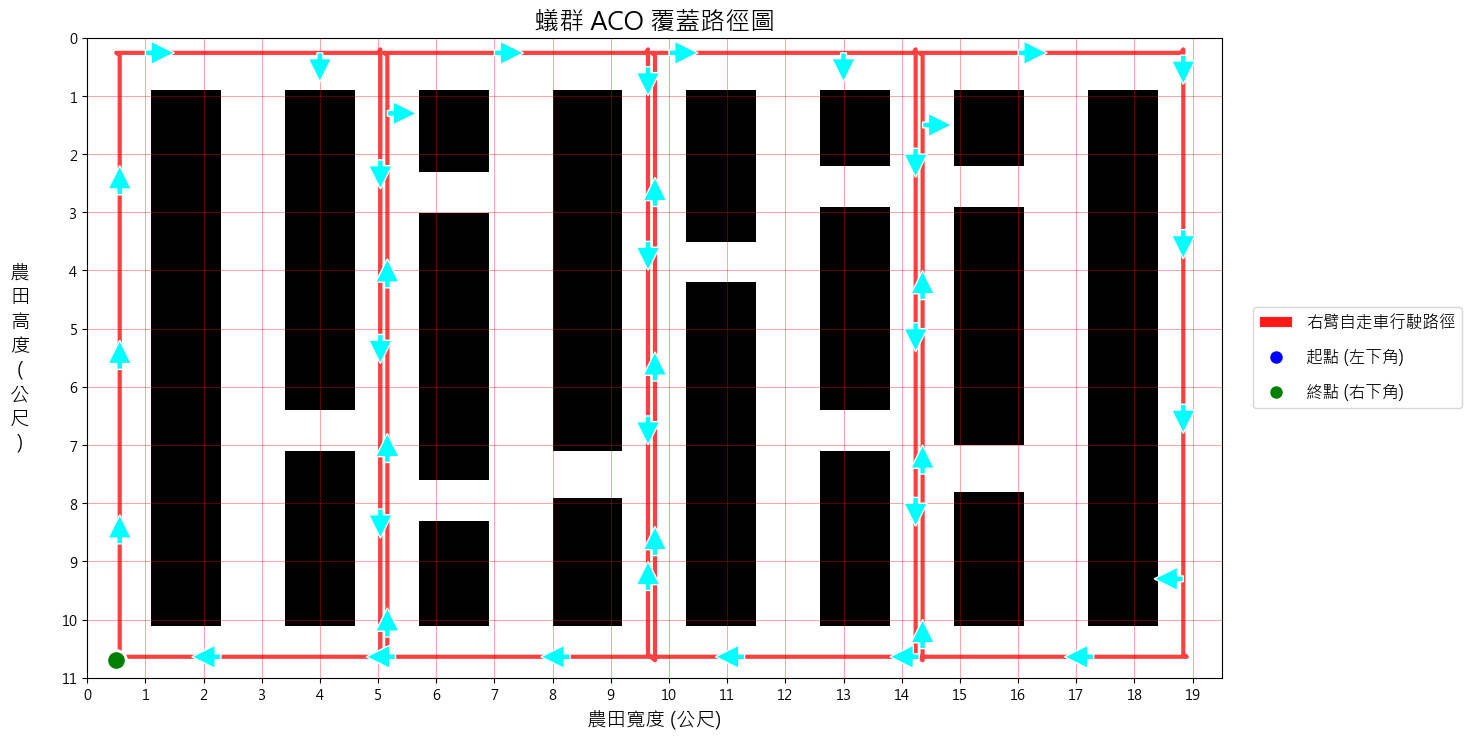

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager, rcParams
import random
from pathlib import Path

# =========================================================
# 🌟 1. 專業細節：自動尋找支援中文的字體
# =========================================================
def set_chinese_font_professional():
    """尋找並設定系統支援的專業中文字體"""
    system_font_paths = [
        "/System/Library/Fonts/PingFang.ttc",      # macOS
        "/System/Library/Fonts/STHeiti Light.ttc", # macOS
        "/Windows/Fonts/simhei.ttf",               # Windows
        "/Windows/Fonts/msjh.ttc",                 # Windows (雅黑)
        "/Windows/Fonts/ArialUnicode.ttf"          # macOS/Windows 開源
    ]
    
    font_family = "SimHei" # 預設字體
    for font_path in system_font_paths:
        if Path(font_path).exists():
            print(f"✅ 找到系統支援的中文字體: {font_path}")
            f_prop = font_manager.FontProperties(fname=font_path)
            rcParams['font.family'] = 'sans-serif'
            rcParams['font.sans-serif'] = [f_prop.get_name(), 'Arial', 'DejaVu Sans']
            rcParams['axes.unicode_minus'] = False 
            return f_prop.get_name()
            
    print("⚠️ 找不到任何系統支援的中文字體，Matplotlib 可能會顯示亂碼！")
    return font_family

# =========================================================
# 🐜 2. 強定向網格蟻群演算法 (Directional Grid ACO)
# =========================================================
class DirectionalACO:
    def __init__(self, grid, ants=20, max_iter=10, alpha=1.0, beta=8.0, rho=0.2):
        self.grid = grid
        self.rows, self.cols = grid.shape
        self.ants = ants
        self.max_iter = max_iter
        self.alpha = alpha
        self.beta = beta  
        self.rho = rho
        self.pheromones = np.ones(grid.shape) * 0.1

    def solve(self, start, end):
        if start == end: return [start]
        
        best_path = None
        best_length = float('inf')

        min_r, max_r = max(0, min(start[0], end[0]) - 3), min(self.rows - 1, max(start[0], end[0]) + 3)
        min_c, max_c = max(0, min(start[1], end[1]) - 3), min(self.cols - 1, max(start[1], end[1]) + 3)

        for _ in range(self.max_iter):
            paths = []
            for _ in range(self.ants):
                path = [start]
                visited = set([start])
                curr = start

                while curr != end:
                    neighbors = []
                    for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nr, nc = curr[0] + dr, curr[1] + dc
                        if min_r <= nr <= max_r and min_c <= nc <= max_c:
                            if self.grid[nr, nc] == 1 and (nr, nc) not in visited:
                                neighbors.append((nr, nc))
                    
                    if not neighbors: break 

                    probs = []
                    dist_curr = abs(curr[0] - end[0]) + abs(curr[1] - end[1])
                    
                    for n in neighbors:
                        tau = self.pheromones[n[0], n[1]] ** self.alpha
                        dist_n = abs(n[0] - end[0]) + abs(n[1] - end[1])
                        eta = 10.0 if dist_n < dist_curr else 1.0 
                        probs.append(tau * (eta ** self.beta))
                    
                    probs = np.array(probs)
                    probs_sum = probs.sum()
                    if probs_sum == 0:
                        next_node = random.choice(neighbors)
                    else:
                        probs /= probs_sum
                        next_node = neighbors[np.random.choice(len(neighbors), p=probs)]

                    path.append(next_node)
                    visited.add(next_node)
                    curr = next_node

                if curr == end:
                    paths.append(path)
                    if len(path) < best_length:
                        best_length = len(path)
                        best_path = path

            self.pheromones *= (1 - self.rho)
            if best_path:
                for p in paths:
                    deposit = 10.0 / len(p)
                    for node in p:
                        self.pheromones[node[0], node[1]] += deposit

        return best_path

# =========================================================
# 🚜 3. 自動生成「右臂專用」跳行航點
# =========================================================
def generate_right_arm_waypoints(grid):
    rows, cols = grid.shape
    col_sums = np.sum(grid, axis=0)
    is_aisle = col_sums > (rows * 0.8)
    
    aisle_centers = []
    in_block = False
    start_c = 0
    for c in range(cols):
        if is_aisle[c]:
            if not in_block:
                start_c = c
                in_block = True
        else:
            if in_block:
                aisle_centers.append((start_c + c - 1) // 2)
                in_block = False
    if in_block: aisle_centers.append((start_c + cols - 1) // 2)
    
    print(f"📡 系統精準偵測到 {len(aisle_centers)} 條走道，中心 X 座標: {aisle_centers}")

    TOP_M = 2
    BOT_M = rows - 3
    
    target_sequence = [
        (0, 'UP'),   
        (2, 'DOWN'), 
        (2, 'UP'),   
        (4, 'DOWN'), 
        (4, 'UP'),   
        (6, 'DOWN'), 
        (6, 'UP'),   
        (8, 'DOWN')  
    ]
    
    start_node = (BOT_M, aisle_centers[0]) 
    waypoints = [start_node]
    
    for aisle_idx, direction in target_sequence:
        c = aisle_centers[aisle_idx]
        if direction == 'UP':
            if waypoints[-1] != (BOT_M, c): waypoints.append((BOT_M, c))
            waypoints.append((TOP_M, c))
        else:
            if waypoints[-1] != (TOP_M, c): waypoints.append((TOP_M, c))
            waypoints.append((BOT_M, c))
            
    waypoints.append(start_node) 
    return waypoints, aisle_centers[0], aisle_centers[-1]

# =========================================================
# 📂 4. 讀取模擬數據模組
# =========================================================
def load_simulation_data(map_file="farm_grid_map.csv", path_file="aco_coverage_path.txt"):
    try:
        aco_matrix = np.loadtxt(map_file, delimiter=",", dtype=int)
        rows, cols = aco_matrix.shape
        print(f"✅ 成功載入地圖尺寸: {rows}x{cols}")
    except FileNotFoundError:
        print(f"❌ 找不到 {map_file}！請先執行建圖程式。")
        return None, None

    try:
        with open(path_file, "r") as f:
            lines = f.readlines()[1:] 
            full_path = []
            for line in lines:
                r, c = map(int, line.strip().split(','))
                full_path.append((r, c))
        print(f"🏁 ACO 路徑讀取完成！總步數：{len(full_path)} 步")
    except FileNotFoundError:
        print(f"❌ 找不到 {path_file}！請先執行路徑規劃程式。")
        return aco_matrix, None
        
    return aco_matrix, full_path

# =========================================================
# 📈 5. 視覺化繪圖模組 (徹底公尺化、防擠壓佈局、強制正向箭頭)
# =========================================================
def visualize_coverage_path(aco_matrix, full_path, cell_size_m=0.1):
    rows, cols = aco_matrix.shape
    
    # 計算物理總尺寸 (公尺)
    w_m = cols * cell_size_m
    h_m = rows * cell_size_m

    fig, ax = plt.subplots(figsize=(16, 8)) 

    # 1. 畫出底圖
    display_grid = np.where(aco_matrix == 1, 255, 0)
    ax.imshow(display_grid, cmap='gray', extent=[0, w_m, h_m, 0])
    
    # 2. 建立「靠右行駛」的視覺偏移座標
    vis_x = []
    vis_y = []
    OFFSET_CELLS = 0.6 # 網格偏移量
    
    for i in range(len(full_path)):
        r, c = full_path[i]
        if i < len(full_path) - 1:
            dr = full_path[i+1][0] - r
            dc = full_path[i+1][1] - c
        else:
            dr = r - full_path[i-1][0]
            dc = c - full_path[i-1][1]
            
        # 轉換為公尺並加入偏移
        if dr < 0:   
            vis_x.append((c + OFFSET_CELLS) * cell_size_m)
            vis_y.append(r * cell_size_m)
        elif dr > 0: 
            vis_x.append((c - OFFSET_CELLS) * cell_size_m)
            vis_y.append(r * cell_size_m)
        elif dc > 0: 
            vis_x.append(c * cell_size_m)
            vis_y.append((r + OFFSET_CELLS) * cell_size_m) 
        elif dc < 0: 
            vis_x.append(c * cell_size_m)
            vis_y.append((r - OFFSET_CELLS) * cell_size_m)
        else:
            vis_x.append(c * cell_size_m)
            vis_y.append(r * cell_size_m)
            
    # 3. 畫出紅線
    ax.plot(vis_x, vis_y, color='red', linewidth=3.0, alpha=0.75)
    
    # 4. 生成「規律距離插值」的螢光青色箭頭
    total_dist_pts = [0]
    for i in range(len(full_path) - 1):
        r1, c1 = full_path[i]
        r2, c2 = full_path[i+1]
        dist = np.sqrt(((r2 - r1)**2 + (c2 - c1)**2)) * cell_size_m
        total_dist_pts.append(total_dist_pts[-1] + dist)
        
    final_m = total_dist_pts[-1]

    regulated_arrow_spacing_m = 3.0
    arrow_positions_m = np.arange(2.0, final_m, regulated_arrow_spacing_m)
    
    arrow_len_m = 5.0 * cell_size_m 
    
    regulated_vis_x = np.interp(arrow_positions_m, total_dist_pts, vis_x)
    regulated_vis_y = np.interp(arrow_positions_m, total_dist_pts, vis_y)
    
    for i in range(len(regulated_vis_x)):
        x_m, y_m = regulated_vis_x[i], regulated_vis_y[i]
        
        if i < len(regulated_vis_x) - 1:
            dx = regulated_vis_x[i+1] - x_m
            dy = regulated_vis_y[i+1] - y_m
        else:
            dx = x_m - regulated_vis_x[i-1]
            dy = y_m - regulated_vis_y[i-1]
            
        if dx != 0 or dy != 0: 
            # ========================================================
            # 🌟 核心修正：強制將方向鎖定為絕對的上下左右 (四正向) 🌟
            # 比較 X 軸和 Y 軸哪一個變化比較大，捨棄掉因為切角產生的微小傾斜
            # ========================================================
            if abs(dx) > abs(dy):
                dy = 0.0  # 強制鎖定為純水平移動
            else:
                dx = 0.0  # 強制鎖定為純垂直移動
                
            norm = np.hypot(dx, dy)
            dx_norm = (dx / norm) * arrow_len_m
            dy_norm = (dy / norm) * arrow_len_m
            
            ax.arrow(x_m, y_m, dx_norm, dy_norm, 
                      shape='full', width=0.1, head_width=0.4, head_length=0.4, 
                      edgecolor='white', facecolor='cyan', length_includes_head=True, zorder=6)

    # 5. 標示起終點 (轉換為公尺)
    ax.plot(full_path[0][1] * cell_size_m, full_path[0][0] * cell_size_m, 'bo', markersize=14, markeredgecolor='white', markeredgewidth=2)
    ax.plot(full_path[-1][1] * cell_size_m, full_path[-1][0] * cell_size_m, 'go', markersize=14, markeredgecolor='white', markeredgewidth=2)

    # 6. 座標軸設定與網格
    ax.set_title("蟻群 ACO 覆蓋路徑圖", fontsize=18)
    
    vertical_y_label = "\n".join("農田高度(公尺)")
    ax.set_ylabel(vertical_y_label, fontsize=14, rotation=0, labelpad=30, ha='center', va='center') 
    ax.set_xlabel("農田寬度 (公尺)", fontsize=14)

    ax.set_xticks(np.arange(0, w_m + 0.1, 1.0)) 
    ax.set_yticks(np.arange(0, h_m + 0.1, 1.0))
    ax.grid(color='red', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # 7. 佈局防擠壓：絕對保留右側空間給圖示
    leg = ax.legend([patches.Rectangle((0,0),1,1, facecolor='red', edgecolor='white', lw=1.5, alpha=0.9),
                     plt.Line2D([], [], color='blue', marker='o', markersize=10, markeredgecolor='white', lw=0),
                     plt.Line2D([], [], color='green', marker='o', markersize=10, markeredgecolor='white', lw=0)],
                    ["右臂自走車行駛路徑", "起點 (左下角)", "終點 (右下角)"], 
                    loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=12, labelspacing=1.0)
    
    # 強制保留畫布右側 18% 的留白，用來放置 legend
    plt.subplots_adjust(left=0.08, right=0.82, top=0.9, bottom=0.1)
    
    plt.show()

# =========================================================
# 🚀 6. 主程式執行區塊
# =========================================================
if __name__ == "__main__":
    set_chinese_font_professional()
    map_matrix, aco_path = load_simulation_data("farm_grid_map.csv", "aco_coverage_path.txt")
    
    if map_matrix is not None and aco_path is not None:
        visualize_coverage_path(map_matrix, aco_path, cell_size_m=0.1)

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager, rcParams
import random
from pathlib import Path


# =========================================================
# 1. 自動尋找支援中文的字體
# =========================================================
def set_chinese_font_professional():
    system_font_paths = [
        "/System/Library/Fonts/PingFang.ttc",
        "/System/Library/Fonts/STHeiti Light.ttc",
        "/Windows/Fonts/simhei.ttf",
        "/Windows/Fonts/msjh.ttc",
        "/Windows/Fonts/ArialUnicode.ttf"
    ]

    font_family = "SimHei"
    for font_path in system_font_paths:
        if Path(font_path).exists():
            print(f"✅ 找到系統支援的中文字體: {font_path}")
            f_prop = font_manager.FontProperties(fname=font_path)
            rcParams["font.family"] = "sans-serif"
            rcParams["font.sans-serif"] = [f_prop.get_name(), "Arial", "DejaVu Sans"]
            rcParams["axes.unicode_minus"] = False
            return f_prop.get_name()

    print("⚠️ 找不到任何系統支援的中文字體，Matplotlib 可能會顯示亂碼！")
    rcParams["font.sans-serif"] = ["DejaVu Sans"]
    rcParams["axes.unicode_minus"] = False
    return font_family


# =========================================================
# 2. 從 image.jpg 產生可通行網格
# =========================================================
def image_to_grid(image_path, grid_w=39, grid_h=22, thresh=110):
    if not Path(image_path).exists():
        raise FileNotFoundError(f"找不到圖片檔案: {image_path}")

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        from PIL import Image
        pil_img = Image.open(image_path).convert("L")
        img = np.array(pil_img)

    h, w = img.shape
    grid = np.zeros((grid_h, grid_w), dtype=int)
    sx, sy = w / grid_w, h / grid_h

    for gy in range(grid_h):
        for gx in range(grid_w):
            x0, x1 = int(gx * sx), int((gx + 1) * sx)
            y0, y1 = int(gy * sy), int((gy + 1) * sy)
            patch = img[y0:y1, x0:x1]
            if patch.size == 0:
                continue
            if patch.mean() > thresh:
                grid[gy, gx] = 1
    return grid


# =========================================================
# 3. 強定向網格蟻群演算法
# =========================================================
class DirectionalACO:
    def __init__(self, grid, ants=20, max_iter=10, alpha=1.0, beta=8.0, rho=0.2):
        self.grid = grid
        self.rows, self.cols = grid.shape
        self.ants = ants
        self.max_iter = max_iter
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.pheromones = np.ones(grid.shape) * 0.1

    def solve(self, start, end):
        if start == end:
            return [start]

        best_path = None
        best_length = float("inf")

        min_r = max(0, min(start[0], end[0]) - 3)
        max_r = min(self.rows - 1, max(start[0], end[0]) + 3)
        min_c = max(0, min(start[1], end[1]) - 3)
        max_c = min(self.cols - 1, max(start[1], end[1]) + 3)

        for _ in range(self.max_iter):
            paths = []

            for _ in range(self.ants):
                path = [start]
                visited = set([start])
                curr = start

                while curr != end:
                    neighbors = []
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = curr[0] + dr, curr[1] + dc
                        if min_r <= nr <= max_r and min_c <= nc <= max_c:
                            if self.grid[nr, nc] == 1 and (nr, nc) not in visited:
                                neighbors.append((nr, nc))

                    if not neighbors:
                        break

                    probs = []
                    dist_curr = abs(curr[0] - end[0]) + abs(curr[1] - end[1])

                    for n in neighbors:
                        tau = self.pheromones[n[0], n[1]] ** self.alpha
                        dist_n = abs(n[0] - end[0]) + abs(n[1] - end[1])
                        eta = 10.0 if dist_n < dist_curr else 1.0
                        probs.append(tau * (eta ** self.beta))

                    probs = np.array(probs)
                    probs_sum = probs.sum()

                    if probs_sum == 0:
                        next_node = random.choice(neighbors)
                    else:
                        probs = probs / probs_sum
                        idx = np.random.choice(len(neighbors), p=probs)
                        next_node = neighbors[idx]

                    path.append(next_node)
                    visited.add(next_node)
                    curr = next_node

                if curr == end:
                    paths.append(path)
                    if len(path) < best_length:
                        best_length = len(path)
                        best_path = path

            self.pheromones *= (1 - self.rho)

            if best_path:
                for p in paths:
                    deposit = 10.0 / len(p)
                    for node in p:
                        self.pheromones[node[0], node[1]] += deposit

        return best_path


# =========================================================
# 4. 自動生成右臂專用跳行航點
# =========================================================
def generate_right_arm_waypoints(grid):
    rows, cols = grid.shape
    col_sums = np.sum(grid, axis=0)
    is_aisle = col_sums > (rows * 0.8)

    aisle_centers = []
    in_block = False
    start_c = 0

    for c in range(cols):
        if is_aisle[c]:
            if not in_block:
                start_c = c
                in_block = True
        else:
            if in_block:
                aisle_centers.append((start_c + c - 1) // 2)
                in_block = False

    if in_block:
        aisle_centers.append((start_c + cols - 1) // 2)

    print(f"📡 系統精準偵測到 {len(aisle_centers)} 條走道，中心 X 座標: {aisle_centers}")

    TOP_M = 2
    BOT_M = rows - 3

    target_sequence = [
        (0, "UP"),
        (2, "DOWN"),
        (2, "UP"),
        (4, "DOWN"),
        (4, "UP"),
        (6, "DOWN"),
        (6, "UP"),
        (8, "DOWN")
    ]

    start_node = (BOT_M, aisle_centers[0])
    waypoints = [start_node]

    for aisle_idx, direction in target_sequence:
        if aisle_idx >= len(aisle_centers):
            break

        c = aisle_centers[aisle_idx]

        if direction == "UP":
            if waypoints[-1] != (BOT_M, c):
                waypoints.append((BOT_M, c))
            waypoints.append((TOP_M, c))
        else:
            if waypoints[-1] != (TOP_M, c):
                waypoints.append((TOP_M, c))
            waypoints.append((BOT_M, c))

    waypoints.append(start_node)
    return waypoints, aisle_centers[0], aisle_centers[-1]


# =========================================================
# 5. 直接從 image.jpg 建立地圖
# =========================================================
def load_simulation_data():
    print("📁 自動從 image.jpg 生成地圖...")
    try:
        grid = image_to_grid("image.jpg", 39, 22, 110)
        print(f"✅ 成功生成地圖尺寸: {grid.shape}")
        return grid
    except FileNotFoundError as e:
        print(f"❌ {e}")
        return None


# =========================================================
# 6. 產生完整覆蓋路徑
# =========================================================
def generate_coverage_path(grid):
    waypoints, first_aisle, last_aisle = generate_right_arm_waypoints(grid)
    print(f"✅ 生成 {len(waypoints)} 個航點")

    full_path = []

    for i in range(len(waypoints) - 1):
        print(f"🐜 ACO 計算第 {i+1}/{len(waypoints)-1} 段: {waypoints[i]} -> {waypoints[i+1]}")
        aco = DirectionalACO(grid)
        seg = aco.solve(waypoints[i], waypoints[i + 1])

        if seg:
            if i > 0:
                seg = seg[1:]
            full_path.extend(seg)
        else:
            print(f"⚠️ 第 {i+1} 段找不到路徑")

    return full_path


# =========================================================
# 7. 視覺化繪圖
# =========================================================
def visualize_coverage_path(aco_matrix, full_path, cell_size_m=0.5):
    if full_path is None or len(full_path) == 0:
        print("❌ 沒有可視化路徑")
        return

    rows, cols = aco_matrix.shape
    w_m = cols * cell_size_m
    h_m = rows * cell_size_m

    fig, ax = plt.subplots(figsize=(16, 8))

    display_grid = np.where(aco_matrix == 1, 255, 0)
    ax.imshow(display_grid, cmap="gray", extent=[0, w_m, h_m, 0])

    vis_x = []
    vis_y = []
    OFFSET_CELLS = 0.6

    for i in range(len(full_path)):
        r, c = full_path[i]

        if i < len(full_path) - 1:
            dr = full_path[i + 1][0] - r
            dc = full_path[i + 1][1] - c
        else:
            dr = r - full_path[i - 1][0]
            dc = c - full_path[i - 1][1]

        if dr < 0:
            vis_x.append((c + OFFSET_CELLS) * cell_size_m)
            vis_y.append(r * cell_size_m)
        elif dr > 0:
            vis_x.append((c - OFFSET_CELLS) * cell_size_m)
            vis_y.append(r * cell_size_m)
        elif dc > 0:
            vis_x.append(c * cell_size_m)
            vis_y.append((r + OFFSET_CELLS) * cell_size_m)
        elif dc < 0:
            vis_x.append(c * cell_size_m)
            vis_y.append((r - OFFSET_CELLS) * cell_size_m)
        else:
            vis_x.append(c * cell_size_m)
            vis_y.append(r * cell_size_m)

    ax.plot(vis_x, vis_y, color="red", linewidth=3.0, alpha=0.75)

    total_dist_pts = [0]
    for i in range(len(full_path) - 1):
        r1, c1 = full_path[i]
        r2, c2 = full_path[i + 1]
        dist = np.sqrt((r2 - r1) ** 2 + (c2 - c1) ** 2) * cell_size_m
        total_dist_pts.append(total_dist_pts[-1] + dist)

    final_m = total_dist_pts[-1]
    regulated_arrow_spacing_m = 3.0
    arrow_positions_m = np.arange(2.0, final_m, regulated_arrow_spacing_m)
    arrow_len_m = 5.0 * cell_size_m

    regulated_vis_x = np.interp(arrow_positions_m, total_dist_pts, vis_x)
    regulated_vis_y = np.interp(arrow_positions_m, total_dist_pts, vis_y)

    for i in range(len(regulated_vis_x)):
        x_m, y_m = regulated_vis_x[i], regulated_vis_y[i]

        if i < len(regulated_vis_x) - 1:
            dx = regulated_vis_x[i + 1] - x_m
            dy = regulated_vis_y[i + 1] - y_m
        else:
            dx = x_m - regulated_vis_x[i - 1]
            dy = y_m - regulated_vis_y[i - 1]

        if dx != 0 or dy != 0:
            if abs(dx) > abs(dy):
                dy = 0.0
            else:
                dx = 0.0

            norm = np.hypot(dx, dy)
            dx_norm = (dx / norm) * arrow_len_m
            dy_norm = (dy / norm) * arrow_len_m

            ax.arrow(
                x_m, y_m, dx_norm, dy_norm,
                shape="full",
                width=0.1,
                head_width=0.4,
                head_length=0.4,
                edgecolor="white",
                facecolor="cyan",
                length_includes_head=True,
                zorder=6
            )

    ax.plot(full_path[0][1] * cell_size_m, full_path[0][0] * cell_size_m,
            "bo", markersize=14, markeredgecolor="white", markeredgewidth=2)
    ax.plot(full_path[-1][1] * cell_size_m, full_path[-1][0] * cell_size_m,
            "go", markersize=14, markeredgecolor="white", markeredgewidth=2)

    ax.set_title("蟻群 ACO 覆蓋路徑圖", fontsize=18)

    vertical_y_label = "\n".join("農田高度(公尺)")
    ax.set_ylabel(vertical_y_label, fontsize=14, rotation=0, labelpad=30, ha="center", va="center")
    ax.set_xlabel("農田寬度 (公尺)", fontsize=14)

    ax.set_xticks(np.arange(0, w_m + 0.1, 1.0))
    ax.set_yticks(np.arange(0, h_m + 0.1, 1.0))
    ax.grid(color="red", linestyle="-", linewidth=0.5, alpha=0.5)

    ax.legend(
        [
            patches.Rectangle((0, 0), 1, 1, facecolor="red", edgecolor="white", lw=1.5, alpha=0.9),
            plt.Line2D([], [], color="blue", marker="o", markersize=10, markeredgecolor="white", lw=0),
            plt.Line2D([], [], color="green", marker="o", markersize=10, markeredgecolor="white", lw=0)
        ],
        ["右臂自走車行駛路徑", "起點 (左下角)", "終點 (右下角)"],
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=12,
        labelspacing=1.0
    )

    plt.subplots_adjust(left=0.08, right=0.82, top=0.9, bottom=0.1)
    plt.savefig("aco_coverage_result.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ 結果已儲存為 aco_coverage_result.png")


# =========================================================
# 8. 主程式
# =========================================================
if __name__ == "__main__":
    set_chinese_font_professional()
    map_matrix = load_simulation_data()

    if map_matrix is not None:
        print("🗺️ 開始生成覆蓋路徑...")
        aco_path = generate_coverage_path(map_matrix)
        print(f"🏁 完整路徑生成完成！總步數：{len(aco_path)}")
        visualize_coverage_path(map_matrix, aco_path, cell_size_m=0.5)
    else:
        print("❌ 地圖載入失敗，請確認 image.jpg 檔案")

✅ 找到系統支援的中文字體: /Windows/Fonts/msjh.ttc
📁 自動從 image.jpg 生成地圖...
❌ 找不到圖片檔案: image.jpg
❌ 地圖載入失敗，請確認 image.jpg 檔案
